In [ ]:
# Install fair-esm and torch
!pip install fair-esm torch

# Also install biopython for parsing fasta files efficiently
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.8 MB/s eta 0:00:00


In [ ]:
import torch
import esm
from Bio import SeqIO

# Load ESM-2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()

# Move model to GPU if available
if torch.cuda.is_available():
    model = model.cuda()
    print("ESM-2 model moved to GPU.")
else:
    print("No GPU available, ESM-2 model running on CPU.")

model.eval()  # Set the model to evaluation mode
batch_converter = alphabet.get_batch_converter()

print("ESM-2 model loaded successfully.")

KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import os

def generate_esm2_embeddings(protein_fasta_path, output_embedding_dir, sequence_batch_size=3, max_sequence_length=1024):
    """Generates ESM-2 embeddings with aggressive memory management."""
    filename = os.path.basename(protein_fasta_path)
    accession = filename.split('_proteins.faa')[0]
    output_path = os.path.join(output_embedding_dir, f'{accession}_esm2_embeddings.npy')

    if os.path.exists(output_path):
        return

    sequences_to_process = []
    for record in SeqIO.parse(protein_fasta_path, "fasta"):
        cleaned_seq = str(record.seq).replace('*', '')
        if cleaned_seq:
            if len(cleaned_seq) > max_sequence_length:
                cleaned_seq = cleaned_seq[:max_sequence_length]
            sequences_to_process.append((record.id, cleaned_seq))

    if not sequences_to_process:
        return

    all_sequence_representations = []
    device = next(model.parameters()).device

    for i in range(0, len(sequences_to_process), sequence_batch_size):
        batch_sequences = sequences_to_process[i:i + sequence_batch_size]

        # 1. Convert to tokens
        _, _, batch_tokens = batch_converter(batch_sequences)
        batch_tokens = batch_tokens.to(device)

        # 2. Forward pass
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[33], return_contacts=False)
            token_representations = results["representations"][33]

        # 3. Extract and average
        for j, (_, seq) in enumerate(batch_sequences):
            embedding = token_representations[j, 1 : len(seq) + 1].mean(0)
            all_sequence_representations.append(embedding.cpu().numpy())

        # 4. CRITICAL: Explicitly clear GPU memory
        del batch_tokens
        del results
        del token_representations
        torch.cuda.empty_cache()

    if all_sequence_representations:
        all_embeddings = np.array(all_sequence_representations)
        np.save(output_path, all_embeddings)
        print(f"Generated embeddings for {accession} ({len(all_sequence_representations)} proteins)")

AttributeError: partially initialized module 'torch' has no attribute '_logging' (most likely due to a circular import)

In [ ]:
import os
import glob

output_protein_dir = "/content/drive/MyDrive/extracted_proteins"
output_embedding_dir = "/content/bacterial_esm2_embeddings"
os.makedirs(output_embedding_dir, exist_ok=True)

protein_fasta_files = glob.glob(os.path.join(output_protein_dir, "*_proteins.faa"))

print(f"Found {len(protein_fasta_files)} bacterial protein FASTA files in total.")

# Filter out files for which embeddings already exist
existing_embedding_files = glob.glob(os.path.join(output_embedding_dir, "*_esm2_embeddings.npy"))
existing_accessions = {os.path.basename(f).split('_esm2_embeddings.npy')[0] for f in existing_embedding_files}

protein_fasta_files_to_process = []
for protein_file in protein_fasta_files:
    filename = os.path.basename(protein_file)
    accession = filename.split('_proteins.faa')[0]
    if accession not in existing_accessions:
        protein_fasta_files_to_process.append(protein_file)

protein_fasta_files = protein_fasta_files_to_process

print(f"Found {len(protein_fasta_files)} bacterial protein FASTA files to process for ESM-2 embeddings after filtering for existing embeddings.")

# --- MODIFICATION START ---
# Reduce the number of files to process to avoid out-of-memory issues.
# You can adjust this number based on your available RAM.
n_bacterial_files_to_process = 10 # Example: process 500 files
if len(protein_fasta_files) > n_bacterial_files_to_process:
    protein_fasta_files = protein_fasta_files[:n_bacterial_files_to_process]
    print(f"Processing a subset of {len(protein_fasta_files)} bacterial protein FASTA files.")
# --- MODIFICATION END ---

for protein_file in protein_fasta_files:
    generate_esm2_embeddings(protein_file, output_embedding_dir)

print("\nAll bacterial protein files processed for ESM-2 embeddings.")

Found 3268 bacterial protein FASTA files in total.
Found 3258 bacterial protein FASTA files to process for ESM-2 embeddings after filtering for existing embeddings.
Processing a subset of 10 bacterial protein FASTA files.
Generated embeddings for GCF_008807295.1 (4589 proteins)
Generated embeddings for GCF_033802465.1 (4578 proteins)
Generated embeddings for GCF_022969555.2 (4860 proteins)
Generated embeddings for GCF_013282335.1 (5016 proteins)
Generated embeddings for GCF_036499365.1 (4539 proteins)
Generated embeddings for GCF_030996645.1 (5267 proteins)
Generated embeddings for GCF_900166955.1 (5188 proteins)
Generated embeddings for GCF_024507875.1 (4525 proteins)
Generated embeddings for GCF_963575395.1 (5041 proteins)
Generated embeddings for GCF_001900415.1 (4491 proteins)

All bacterial protein files processed for ESM-2 embeddings.


In [ ]:
viral_output_protein_dir = "/content/phage_genomes/proteins"
viral_output_embedding_dir = "/content/viral_esm2_embeddings"
os.makedirs(viral_output_embedding_dir, exist_ok=True)

viral_protein_fasta_files = glob.glob(os.path.join(viral_output_protein_dir, "*_proteins.faa"))

print(f"Found {len(viral_protein_fasta_files)} viral protein FASTA files in total.")

# Filter out files for which embeddings already exist
existing_viral_embedding_files = glob.glob(os.path.join(viral_output_embedding_dir, "*_esm2_embeddings.npy"))
existing_viral_accessions = {os.path.basename(f).split('_esm2_embeddings.npy')[0] for f in existing_viral_embedding_files}

viral_protein_fasta_files_to_process = []
for protein_file in viral_protein_fasta_files:
    filename = os.path.basename(protein_file)
    accession = filename.split('_proteins.faa')[0]
    if accession not in existing_viral_accessions:
        viral_protein_fasta_files_to_process.append(protein_file)

viral_protein_fasta_files = viral_protein_fasta_files_to_process

print(f"Found {len(viral_protein_fasta_files)} viral protein FASTA files to process for ESM-2 embeddings after filtering for existing embeddings.")

# --- MODIFICATION START ---
# Reduce the number of files to process to avoid out-of-memory issues.
# You can adjust this number based on your available RAM.
n_viral_files_to_process = 250 # Example: process 100 files
if len(viral_protein_fasta_files) > n_viral_files_to_process:
    viral_protein_fasta_files = viral_protein_fasta_files[:n_viral_files_to_process]
    print(f"Processing a subset of {len(viral_protein_fasta_files)} viral protein FASTA files.")
# --- MODIFICATION END ---

for protein_file in viral_protein_fasta_files:
    generate_esm2_embeddings(protein_file, viral_output_embedding_dir)

print("\nAll viral protein files processed for ESM-2 embeddings.")

Found 2595 viral protein FASTA files in total.
Found 2495 viral protein FASTA files to process for ESM-2 embeddings after filtering for existing embeddings.
Processing a subset of 250 viral protein FASTA files.
Generated embeddings for KU878969 (264 proteins)
Generated embeddings for KF562341 (263 proteins)
Generated embeddings for PX759567 (51 proteins)
Generated embeddings for OR352934 (49 proteins)
Generated embeddings for PZ171032 (204 proteins)
Generated embeddings for OP434518 (57 proteins)
Generated embeddings for KX266440 (6 proteins)
Generated embeddings for MK373799 (181 proteins)
Generated embeddings for OL539445 (84 proteins)
Generated embeddings for KX266390 (6 proteins)
Generated embeddings for KP719132 (86 proteins)
Generated embeddings for OR979723 (77 proteins)
Generated embeddings for KX266621 (6 proteins)
Generated embeddings for PZ168832 (101 proteins)
Generated embeddings for KP682385 (91 proteins)
Generated embeddings for KX266313 (6 proteins)
Generated embeddings

In [ ]:
import numpy as np
import os
import glob

# Define input and output directories for bacterial embeddings
bacterial_input_embedding_dir = "/content/bacterial_esm2_embeddings"
bacterial_normalized_output_dir = "/content/bacterial_esm2_embeddings_normalized"
os.makedirs(bacterial_normalized_output_dir, exist_ok=True)

print(f"Normalizing bacterial embeddings from: {bacterial_input_embedding_dir}")

# Process bacterial embeddings
bacterial_embedding_files = glob.glob(os.path.join(bacterial_input_embedding_dir, "*_esm2_embeddings.npy"))
for i, file_path in enumerate(bacterial_embedding_files):
    try:
        embeddings = np.load(file_path)
        # Perform L2 normalization
        # Add a small epsilon to avoid division by zero for zero vectors
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        normalized_embeddings = embeddings / (norms + 1e-12)

        output_file_path = os.path.join(bacterial_normalized_output_dir, os.path.basename(file_path))
        np.save(output_file_path, normalized_embeddings)
        print(f"Normalized and saved bacterial embeddings for {os.path.basename(file_path)} ({i+1}/{len(bacterial_embedding_files)})")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

print("\nAll bacterial embeddings normalized and saved.")

# Define input and output directories for viral embeddings
viral_input_embedding_dir = "/content/viral_esm2_embeddings"
viral_normalized_output_dir = "/content/viral_esm2_embeddings_normalized"
os.makedirs(viral_normalized_output_dir, exist_ok=True)

print(f"\nNormalizing viral embeddings from: {viral_input_embedding_dir}")

# Process viral embeddings
viral_embedding_files = glob.glob(os.path.join(viral_input_embedding_dir, "*_esm2_embeddings.npy"))
for i, file_path in enumerate(viral_embedding_files):
    try:
        embeddings = np.load(file_path)
        # Perform L2 normalization
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        normalized_embeddings = embeddings / (norms + 1e-12)

        output_file_path = os.path.join(viral_normalized_output_dir, os.path.basename(file_path))
        np.save(output_file_path, normalized_embeddings)
        print(f"Normalized and saved viral embeddings for {os.path.basename(file_path)} ({i+1}/{len(viral_embedding_files)})")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

print("\nAll viral embeddings normalized and saved.")


Normalizing bacterial embeddings from: /content/bacterial_esm2_embeddings
Normalized and saved bacterial embeddings for GCF_024507875.1_esm2_embeddings.npy (1/20)
Normalized and saved bacterial embeddings for GCF_900166955.1_esm2_embeddings.npy (2/20)
Normalized and saved bacterial embeddings for GCF_905330875.2_esm2_embeddings.npy (3/20)
Normalized and saved bacterial embeddings for GCF_001705405.1_esm2_embeddings.npy (4/20)
Normalized and saved bacterial embeddings for GCF_963575395.1_esm2_embeddings.npy (5/20)
Normalized and saved bacterial embeddings for GCF_033802465.1_esm2_embeddings.npy (6/20)
Normalized and saved bacterial embeddings for GCF_001900415.1_esm2_embeddings.npy (7/20)
Normalized and saved bacterial embeddings for GCF_013282335.1_esm2_embeddings.npy (8/20)
Normalized and saved bacterial embeddings for GCF_030996645.1_esm2_embeddings.npy (9/20)
Normalized and saved bacterial embeddings for GCF_022969555.2_esm2_embeddings.npy (10/20)
Normalized and saved bacterial embe

## Running the GNN

In [ ]:
!pip install torch_geometric
# Optional: install additional dependencies for better performance, aligning with PyTorch 2.3.0 and CUDA 12.1 wheels
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 141.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 124.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 57.4 MB/s eta 0:00:00


### 1. Data Preparation: Converting Embeddings to Graphs
In this step, we'll treat each protein as a node. Since prophages are continuous regions in a genome, we define edges between proteins that are neighbors in the FASTA file (genomic order).

In [ ]:
import torch
from torch_geometric.data import Data, Dataset
import numpy as np
import os

def create_graph_from_embeddings(embedding_path, is_prophage=False):
    """
    Converts saved embeddings into a PyG Data object.
    Edges are created between consecutive proteins in the genome.
    """
    x = torch.from_numpy(np.load(embedding_path)).float()
    num_nodes = x.size(0)

    # Create edges for consecutive proteins: (0,1), (1,2), ..., (n-1, n)
    # We make it undirected for GraphSAGE
    edge_index = torch.stack([
        torch.cat([torch.arange(0, num_nodes - 1), torch.arange(1, num_nodes)]),
        torch.cat([torch.arange(1, num_nodes), torch.arange(0, num_nodes - 1)])
    ], dim=0)

    # Target label: for now, we assume viral = 1, bacterial = 0
    # In a real scenario, you'd need segment-level labels for the bacterial genome
    y = torch.full((num_nodes,), 1 if is_prophage else 0, dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

# Example of loading one graph
# sample_graph = create_graph_from_embeddings(bacterial_normalized_output_dir + '/some_file.npy')
print("Graph creation function defined.")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


Graph creation function defined.


### 2. Defining the GraphSAGE Model
We will use the `SAGEConv` layer from PyTorch Geometric.

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ProphageSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(ProphageSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# ESM-2 650M has 1280 dimensions
model_gnn = ProphageSAGE(in_channels=1280, hidden_channels=256, out_channels=2)
print(model_gnn)

ProphageSAGE(
  (conv1): SAGEConv(1280, 256, aggr=mean)
  (conv2): SAGEConv(256, 2, aggr=mean)
)


### 3. Creating the Training and Validation Datasets
We will combine our normalized viral embeddings (Class 1) and bacterial embeddings (Class 0) into a list of graphs for training.

In [ ]:
import random

def prepare_dataset(bacterial_dir, viral_dir, limit_bacterial=20, limit_viral=250):
    dataset = []

    # Load Bacterial Graphs (Class 0)
    bac_files = glob.glob(os.path.join(bacterial_dir, "*.npy"))[:limit_bacterial]
    for f in bac_files:
        dataset.append(create_graph_from_embeddings(f, is_prophage=False))

    # Load Viral Graphs (Class 1)
    vir_files = glob.glob(os.path.join(viral_dir, "*.npy"))[:limit_viral]
    for f in vir_files:
        dataset.append(create_graph_from_embeddings(f, is_prophage=True))

    random.shuffle(dataset)
    return dataset

# Create the dataset using the normalized directories
full_dataset = prepare_dataset(bacterial_normalized_output_dir, viral_normalized_output_dir)

# Split into Train (80%) and Test (20%)
train_size = int(0.8 * len(full_dataset))
train_data = full_dataset[:train_size]
test_data = full_dataset[train_size:]

print(f"Total graphs: {len(full_dataset)}")
print(f"Training graphs: {len(train_data)}, Testing graphs: {len(test_data)}")

Total graphs: 270
Training graphs: 216, Testing graphs: 54


### 4. Handling Imbalance
Since bacterial genomes have many more proteins than phages, we calculate class weights to make the model pay more attention to the viral proteins.

In [ ]:
def calculate_weights(dataset):
    all_y = torch.cat([data.y for data in dataset])
    class_counts = torch.bincount(all_y)
    weights = 1.0 / class_counts.float()
    return weights / weights.sum()

weights = calculate_weights(train_data).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)
print(f"Computed class weights: {weights}")

Computed class weights: tensor([0.2507, 0.7493], device='cuda:0')


### 5. Training the GraphSAGE Model
We will define a standard training loop using CrossEntropyLoss, as this is a classification task (Viral vs. Bacterial).

In [ ]:
from torch_geometric.loader import DataLoader

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gnn = model_gnn.to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.0005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model_gnn.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model_gnn(data.x, data.edge_index)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(loader):
    model_gnn.eval()
    correct = 0
    total_nodes = 0
    for data in loader:
        data = data.to(device)
        out = model_gnn(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        total_nodes += data.num_nodes
    return correct / total_nodes

for epoch in range(1, 16):
    loss = train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Loss: 0.0642, Train Acc: 0.8768, Test Acc: 0.8766
Epoch: 002, Loss: 0.0581, Train Acc: 0.8910, Test Acc: 0.8931
Epoch: 003, Loss: 0.0621, Train Acc: 0.8862, Test Acc: 0.8875
Epoch: 004, Loss: 0.0572, Train Acc: 0.8799, Test Acc: 0.8799
Epoch: 005, Loss: 0.0543, Train Acc: 0.8475, Test Acc: 0.8420
Epoch: 006, Loss: 0.0533, Train Acc: 0.8344, Test Acc: 0.8267
Epoch: 007, Loss: 0.0543, Train Acc: 0.8871, Test Acc: 0.8883
Epoch: 008, Loss: 0.0551, Train Acc: 0.8807, Test Acc: 0.8804
Epoch: 009, Loss: 0.0548, Train Acc: 0.8522, Test Acc: 0.8474
Epoch: 010, Loss: 0.0617, Train Acc: 0.8945, Test Acc: 0.8982
Epoch: 011, Loss: 0.0470, Train Acc: 0.9263, Test Acc: 0.9328
Epoch: 012, Loss: 0.0535, Train Acc: 0.8730, Test Acc: 0.8723
Epoch: 013, Loss: 0.0602, Train Acc: 0.8499, Test Acc: 0.8466
Epoch: 014, Loss: 0.0554, Train Acc: 0.8991, Test Acc: 0.9032
Epoch: 015, Loss: 0.0528, Train Acc: 0.9139, Test Acc: 0.9202


## Identifying regions

### 6. Inference Function
This function takes a full bacterial genome, predicts labels for every protein, and helps you identify where the 'viral' clusters (prophages) are located.

In [ ]:
import matplotlib.pyplot as plt

def predict_prophage_regions(embedding_path, model, threshold=0.5):
    model.eval()
    data = create_graph_from_embeddings(embedding_path).to(device)

    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

    # Plotting the 'viral' probability across the genome
    plt.figure(figsize=(15, 4))
    plt.plot(probs, label='Viral Probability', color='blue', alpha=0.6)
    plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
    plt.title(f"Prophage Prediction for {os.path.basename(embedding_path)}")
    plt.xlabel("Protein Index (Genomic Position)")
    plt.ylabel("Probability")
    plt.legend()
    plt.show()

    return probs

# Example usage (uncomment once training is finished):
# example_file = bacterial_normalized_output_dir + '/' + os.listdir(bacterial_normalized_output_dir)[0]
# probabilities = predict_prophage_regions(example_file, model_gnn)

### 7. Extracting Predicted Regions
This step converts the raw probabilities into a list of specific prophage regions with start and end indices.

In [ ]:
def extract_regions(probs, threshold=0.5, min_length=10, gap_tolerance=2):
    """
    Groups proteins into regions based on a probability threshold.
    - min_length: Minimum number of proteins to be considered a prophage.
    - gap_tolerance: Allows small gaps (bacterial-like proteins) within a viral region.
    """
    regions = []
    current_region = []
    gap_count = 0

    for i, p in enumerate(probs):
        if p >= threshold:
            current_region.append(i)
            gap_count = 0
        elif current_region:
            gap_count += 1
            if gap_count > gap_tolerance:
                if len(current_region) >= min_length:
                    regions.append((current_region[0], current_region[-1]))
                current_region = []
                gap_count = 0
            else:
                # Treat as part of the region temporarily
                current_region.append(i)

    if len(current_region) >= min_length:
        regions.append((current_region[0], current_region[-1]))

    return regions

# Example of how to call it
# probs = predict_prophage_regions(some_file, model_gnn)
# regions = extract_regions(probs)
# print(f"Found {len(regions)} candidate prophage(s): {regions}")

### 8. Saving the Model
We save the model state to disk so it can be used for later analysis or deployment.

In [ ]:
model_save_path = 'prophage_sage_model.pt'
torch.save({
    'model_state_dict': model_gnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'in_channels': 1280,
    'hidden_channels': 256,
    'out_channels': 2
}, model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to prophage_sage_model.pt


### 9. Example Usage: Predicting on 'genome.npy'
This example demonstrates how to load the model and perform inference on a specific unlabelled genome file.

### 9.1 Normalizing the `genome.npy` Embeddings

The `genome.npy` file used for inference was not normalized, whereas the training data (`bacterial_esm2_embeddings_normalized` and `viral_esm2_embeddings_normalized`) was. It's crucial for the input data to match the characteristics of the training data. This step performs L2 normalization on the `genome.npy` embeddings.

In [ ]:
import numpy as np
import os

# Path to the unnormalized genome embeddings
genome_embedding_path = 'genome.npy'
normalized_genome_embedding_path = 'genome_normalized.npy'

if os.path.exists(genome_embedding_path):
    try:
        embeddings = np.load(genome_embedding_path)
        # Perform L2 normalization, adding a small epsilon to avoid division by zero
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        normalized_embeddings = embeddings / (norms + 1e-12)

        np.save(normalized_genome_embedding_path, normalized_embeddings)
        print(f"Normalized embeddings from {genome_embedding_path} and saved to {normalized_genome_embedding_path}")
    except Exception as e:
        print(f"Error processing {genome_embedding_path}: {e}")
else:
    print(f"File {genome_embedding_path} not found. Please ensure it is in the current directory.")

Normalized embeddings from genome.npy and saved to genome_normalized.npy


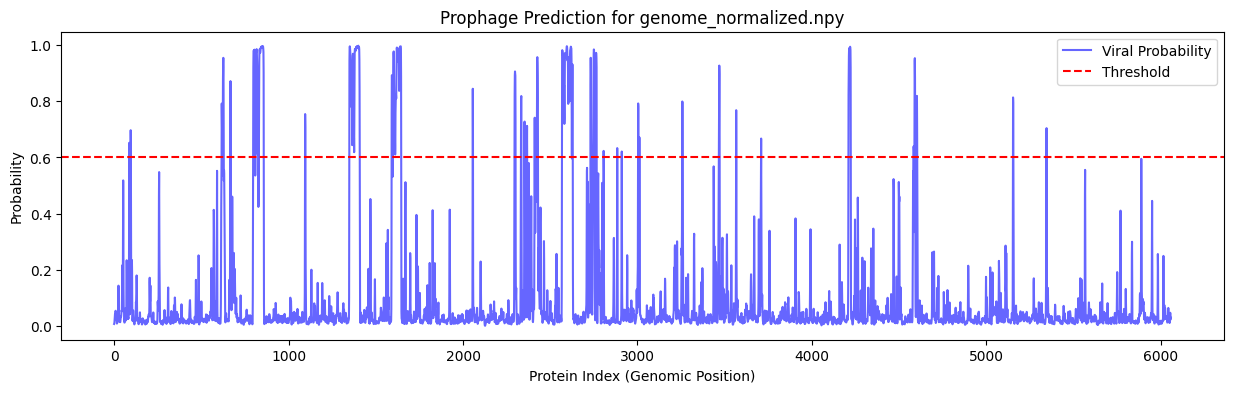


Analysis complete for genome_normalized.npy:
Candidate Prophage 1: Protein Index 797 to 828 (Length: 32 proteins)
Candidate Prophage 2: Protein Index 830 to 859 (Length: 30 proteins)
Candidate Prophage 3: Protein Index 1349 to 1410 (Length: 62 proteins)
Candidate Prophage 4: Protein Index 1591 to 1647 (Length: 57 proteins)
Candidate Prophage 5: Protein Index 2567 to 2631 (Length: 65 proteins)
Candidate Prophage 6: Protein Index 2744 to 2756 (Length: 13 proteins)
Candidate Prophage 7: Protein Index 4210 to 4224 (Length: 15 proteins)


In [ ]:
# 0. Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize a new model instance with the same architecture
in_channels = 1280
hidden_channels = 256
out_channels = 2

inference_model = ProphageSAGE(in_channels, hidden_channels, out_channels).to(device)

# 2. Load the saved weights
checkpoint = torch.load('prophage_sage_model.pt')
inference_model.load_state_dict(checkpoint['model_state_dict'])
inference_model.eval()

# 3. Path to your specific genome file (now using the normalized version)
genome_file = 'genome_normalized.npy'

# Check if file exists before running
if os.path.exists(genome_file):
    # 4. Predict probabilities across the genome
    # This also generates the visualization plot
    probs = predict_prophage_regions(genome_file, inference_model, threshold=0.6)

    # 5. Extract specific start and end indices
    detected_regions = extract_regions(probs, threshold=0.6, min_length=10, gap_tolerance=2)

    print(f"\nAnalysis complete for {genome_file}:")
    if detected_regions:
        for idx, (start, end) in enumerate(detected_regions):
            print(f"Candidate Prophage {idx+1}: Protein Index {start} to {end} (Length: {end-start+1} proteins)")
    else:
        print("No prophage regions detected meeting the length criteria.")
else:
    print(f"File {genome_file} not found. Please ensure it is in the current directory and has been normalized.")

### 10. Mapping Protein Indices to Genomic Coordinates
This function parses the original FASTA file to find the start and end base-pair positions for each protein, then uses our GNN predictions to define the exact genomic boundaries of the prophage.

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.2 MB/s eta 0:00:00


In [ ]:
import re
from Bio import SeqIO

def get_genomic_coords(fasta_path, predicted_regions):
    """
    Maps protein index regions to genomic base-pair coordinates.
    Assumes FASTA headers contain location info like 'U00096.3_1110 # 1197533 # 1198228 # -1 # ...'
    """
    records = list(SeqIO.parse(fasta_path, "fasta"))
    final_coordinates = []

    print(f"Processing {len(predicted_regions)} predicted regions.")

    for start_idx, end_idx in predicted_regions:
        # Ensure indices are within bounds
        if start_idx < 0 or start_idx >= len(records):
            print(f"Warning: start_idx {start_idx} out of bounds ({len(records)} records).")
            continue
        if end_idx < 0 or end_idx >= len(records):
            print(f"Warning: end_idx {end_idx} out of bounds ({len(records)} records).")
            continue

        # Get the first and last protein of the predicted region
        first_protein_description = records[start_idx].description
        last_protein_description = records[end_idx].description

        print(f"First protein description for region ({start_idx}, {end_idx}): {first_protein_description}")
        print(f"Last protein description for region ({start_idx}, {end_idx}): {last_protein_description}")

        # Use regex to find genomic coordinates in the description
        # The regex now looks for numbers surrounded by '#'
        coords_start = re.findall(r'# (\d+) # (\d+) #', first_protein_description)
        coords_end = re.findall(r'# (\d+) # (\d+) #', last_protein_description)

        if coords_start and coords_end:
            # genomic_start is the start coordinate of the first protein
            genomic_start = coords_start[0][0]
            # genomic_end is the end coordinate of the last protein
            genomic_end = coords_end[0][1]
            final_coordinates.append({
                'protein_range': (start_idx, end_idx),
                'genomic_range': (genomic_start, genomic_end)
            })
            print(f"Extracted genomic coordinates: {genomic_start}..{genomic_end}")
        else:
            print(f"Could not find genomic coordinates in descriptions for region ({start_idx}, {end_idx}).")

    return final_coordinates

# Example usage:
fasta_source = "/content/genome_proteins.faa"
genomic_prophages = get_genomic_coords(fasta_source, detected_regions)
if genomic_prophages:
    for p in genomic_prophages:
        print(f"Prophage at BP {p['genomic_range'][0]} to {p['genomic_range'][1]}")
else:
    print("No genomic prophage regions found or extracted.")

Processing 10 predicted regions.
First protein description for region (614, 635): FM209186.1_615 # 664333 # 665103 # -1 # ID=1_615;partial=00;start_type=ATG;rbs_motif=None;rbs_spacer=None;gc_cont=0.656
Last protein description for region (614, 635): FM209186.1_636 # 680128 # 680385 # 1 # ID=1_636;partial=00;start_type=ATG;rbs_motif=GGAG/GAGG;rbs_spacer=5-10bp;gc_cont=0.690
Extracted genomic coordinates: 664333..680385
First protein description for region (796, 860): FM209186.1_797 # 860944 # 862737 # -1 # ID=1_797;partial=00;start_type=ATG;rbs_motif=AGGAG;rbs_spacer=5-10bp;gc_cont=0.688
Last protein description for region (796, 860): FM209186.1_861 # 907338 # 908594 # -1 # ID=1_861;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=5-10bp;gc_cont=0.663
Extracted genomic coordinates: 860944..908594
First protein description for region (1348, 1410): FM209186.1_1349 # 1433854 # 1434957 # -1 # ID=1_1349;partial=00;start_type=ATG;rbs_motif=GGA/GAG/AGG;rbs_spacer=5-10bp;gc_cont=0.599

In [ ]:
import pandas as pd

# Prepare data for DataFrame
data_for_df = []
for i, prophage in enumerate(genomic_prophages):
    region_label = f"Prophage_{i+1}"
    # Convert string coordinates to integers for calculation
    genomic_start = int(prophage['genomic_range'][0])
    genomic_end = int(prophage['genomic_range'][1])

    # Calculate length (assuming 1-based indexing for genomic coordinates)
    length = genomic_end - genomic_start + 1

    data_for_df.append({
        'Region Label': region_label,
        'Start (BP)': genomic_start,
        'End (BP)': genomic_end,
        'Length (BP)': length
    })

# Create DataFrame
prophage_df = pd.DataFrame(data_for_df)

# Display DataFrame
print("Generated Prophage Regions DataFrame:")
print(prophage_df)

# Save to CSV
output_csv_path = 'prophage_regions.csv'
prophage_df.to_csv(output_csv_path, index=False)
print(f"\nProphage regions saved to {output_csv_path}")

Generated Prophage Regions DataFrame:
  Region Label  Start (BP)  End (BP)  Length (BP)
0   Prophage_1      664333    680131        15799
1   Prophage_2      860944    908594        47651
2   Prophage_3     1433854   1480207        46354
3   Prophage_4     1685013   1723970        38958
4   Prophage_5     2523507   2545357        21851
5   Prophage_6     2690501   2742924        52424
6   Prophage_7     2870707   2881548        10842
7   Prophage_8     4545251   4557158        11908
8   Prophage_9     4932820   4960090        27271

Prophage regions saved to prophage_regions.csv


# Tests for the model

## Training History

Epoch: 001, Loss: 0.0611, Train Acc: 0.8664, Test Acc: 0.8650
Epoch: 002, Loss: 0.0527, Train Acc: 0.8749, Test Acc: 0.8746
Epoch: 003, Loss: 0.0554, Train Acc: 0.8925, Test Acc: 0.8955
Epoch: 004, Loss: 0.0495, Train Acc: 0.9147, Test Acc: 0.9212
Epoch: 005, Loss: 0.0516, Train Acc: 0.9124, Test Acc: 0.9182
Epoch: 006, Loss: 0.0632, Train Acc: 0.8545, Test Acc: 0.8503
Epoch: 007, Loss: 0.0514, Train Acc: 0.8868, Test Acc: 0.8880
Epoch: 008, Loss: 0.0478, Train Acc: 0.8667, Test Acc: 0.8655
Epoch: 009, Loss: 0.0561, Train Acc: 0.9148, Test Acc: 0.9218
Epoch: 010, Loss: 0.0543, Train Acc: 0.9148, Test Acc: 0.9213
Epoch: 011, Loss: 0.0580, Train Acc: 0.9138, Test Acc: 0.9201
Epoch: 012, Loss: 0.0497, Train Acc: 0.9299, Test Acc: 0.9371
Epoch: 013, Loss: 0.0518, Train Acc: 0.8719, Test Acc: 0.8705
Epoch: 014, Loss: 0.0561, Train Acc: 0.9244, Test Acc: 0.9320
Epoch: 015, Loss: 0.0525, Train Acc: 0.8994, Test Acc: 0.9034


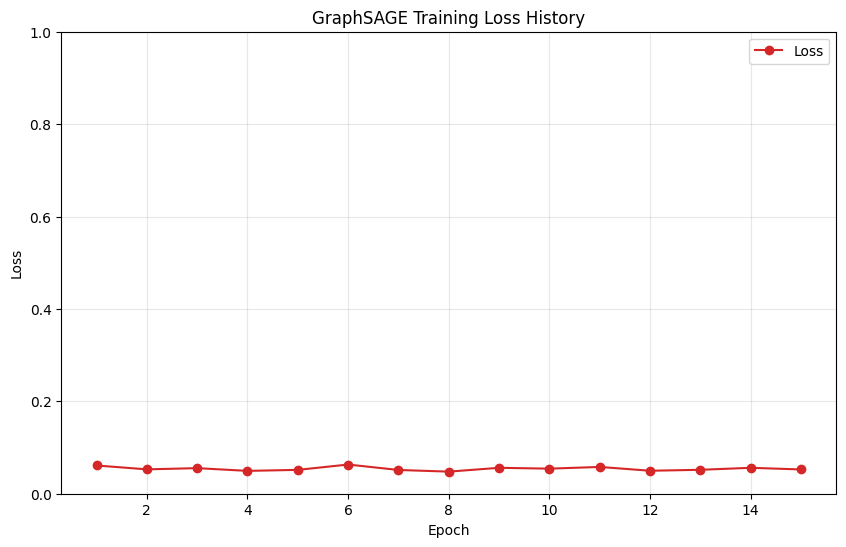

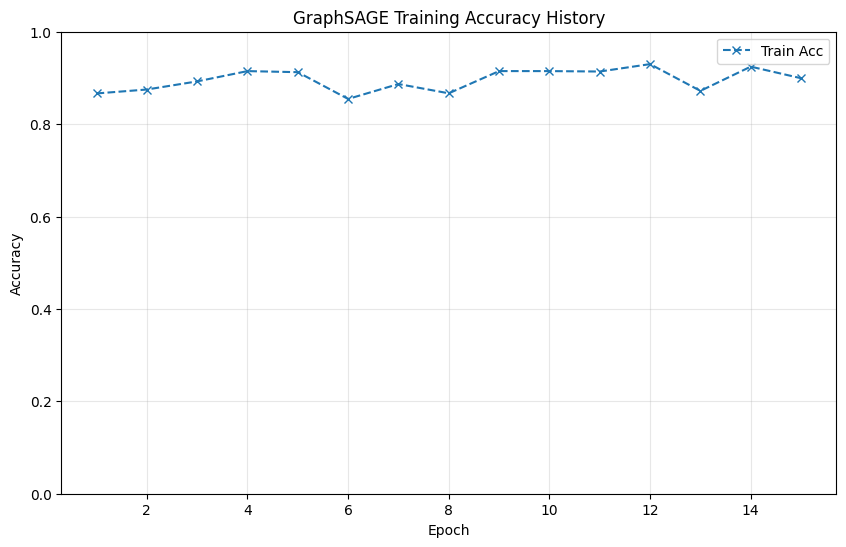

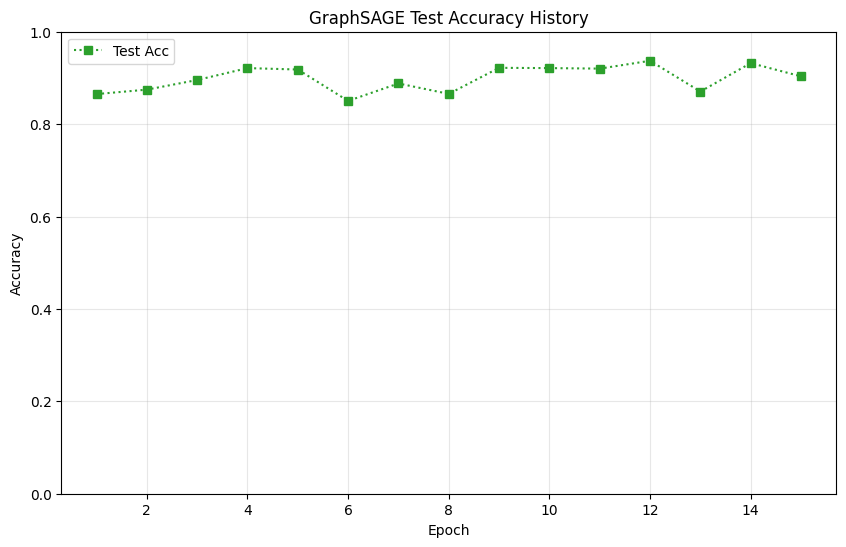

In [ ]:
import matplotlib.pyplot as plt

# Re-initializing lists to store history
history = {"loss": [], "train_acc": [], "test_acc": []}

# Training loop with history tracking
for epoch in range(1, 16):
    loss = train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)

    history["loss"].append(loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

# Plotting Loss History
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), history['loss'], color='tab:red', label='Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GraphSAGE Training Loss History')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([0, 1]) # Set y-axis limit
plt.show()

# Plotting Training Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), history['train_acc'], color='tab:blue', label='Train Acc', linestyle='--', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GraphSAGE Training Accuracy History')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([0, 1]) # Set y-axis limit
plt.show()

# Plotting Test Accuracy History
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), history['test_acc'], color='tab:green', label='Test Acc', linestyle=':', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GraphSAGE Test Accuracy History')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim([0, 1]) # Set y-axis limit
plt.show()

## AUROC curve

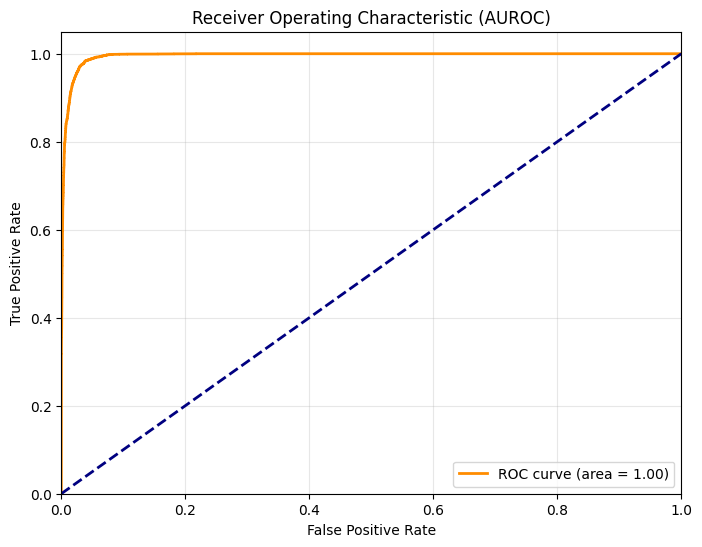

In [ ]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

def plot_auroc(loader, model, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            # Get probability for the viral class (index 1)
            probs = F.softmax(logits, dim=1)[:, 1]

            all_probs.append(probs.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    # Flatten the lists
    y_score = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (AUROC)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Generate the AUROC graph using the test dataset
plot_auroc(test_loader, model_gnn, device)

## Measures (F1, Precision, Recall)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import torch
import numpy as np
import torch.nn.functional as F # Import functional for softmax

def calculate_final_metrics(loader, model, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            # Convert logits to probabilities and apply the threshold
            probs = F.softmax(logits, dim=1)[:, 1] # Probability of the positive class (Viral)
            preds = (probs >= threshold).long() # Convert probabilities to binary predictions based on threshold

            all_preds.append(preds.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    # Flatten the results
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    report_dict = classification_report(y_true, y_pred, target_names=['Bacterial (0)', 'Viral (1)'], output_dict=True, zero_division=0)
    report_str = classification_report(y_true, y_pred, target_names=['Bacterial (0)', 'Viral (1)'], zero_division=0)

    print(f"Metrics at Threshold: {threshold:.4f}")
    print(f"Final Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report_str)

    # Explicitly print combined metrics (weighted avg)
    weighted_precision = report_dict['weighted avg']['precision']
    weighted_recall = report_dict['weighted avg']['recall']
    weighted_f1 = report_dict['weighted avg']['f1-score']
    print(f"\nCombined Metrics (Weighted Average):\n  Precision: {weighted_precision:.4f}\n  Recall: {weighted_recall:.4f}\n  F1-score: {weighted_f1:.4f}")

# Run the metrics calculation on the test set with a default threshold of 0.5
print("--- Metrics with default threshold (0.5) ---")
calculate_final_metrics(test_loader, model_gnn, device, threshold=0.5)

# Run the metrics calculation with the optimal threshold found previously
optimal_threshold = 0.9697 # From previous cell's output
print("\n--- Metrics with Optimal F1-measure Threshold ---")
calculate_final_metrics(test_loader, model_gnn, device, threshold=optimal_threshold)

--- Metrics with default threshold (0.5) ---
Metrics at Threshold: 0.5000
Final Accuracy: 0.9034

Classification Report:
               precision    recall  f1-score   support

Bacterial (0)       1.00      0.88      0.93     24441
    Viral (1)       0.69      1.00      0.82      6636

     accuracy                           0.90     31077
    macro avg       0.84      0.94      0.88     31077
 weighted avg       0.93      0.90      0.91     31077


Combined Metrics (Weighted Average):
  Precision: 0.9333
  Recall: 0.9034
  F1-score: 0.9092

--- Metrics with Optimal F1-measure Threshold ---
Metrics at Threshold: 0.9697
Final Accuracy: 0.9711

Classification Report:
               precision    recall  f1-score   support

Bacterial (0)       0.99      0.98      0.98     24441
    Viral (1)       0.92      0.95      0.93      6636

     accuracy                           0.97     31077
    macro avg       0.95      0.96      0.96     31077
 weighted avg       0.97      0.97      0.97    

In [ ]:
from sklearn.metrics import f1_score

def find_optimal_threshold(loader, model, device, num_thresholds=100):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            probs = F.softmax(logits, dim=1)[:, 1] # Probability of the positive class (Viral)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    y_score = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    thresholds = np.linspace(0, 1, num_thresholds)
    optimal_f1 = -1
    optimal_threshold = 0

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        current_f1 = f1_score(y_true, y_pred)
        if current_f1 > optimal_f1:
            optimal_f1 = current_f1
            optimal_threshold = t

    return optimal_threshold, optimal_f1

# Find and print the optimal threshold and F1-measure
optimal_threshold, max_f1 = find_optimal_threshold(test_loader, model_gnn, device)
print(f"Optimal Threshold to Maximize F1-measure: {optimal_threshold:.4f}")
print(f"Maximum F1-measure at this threshold: {max_f1:.4f}")

Optimal Threshold to Maximize F1-measure: 0.9697
Maximum F1-measure at this threshold: 0.9338


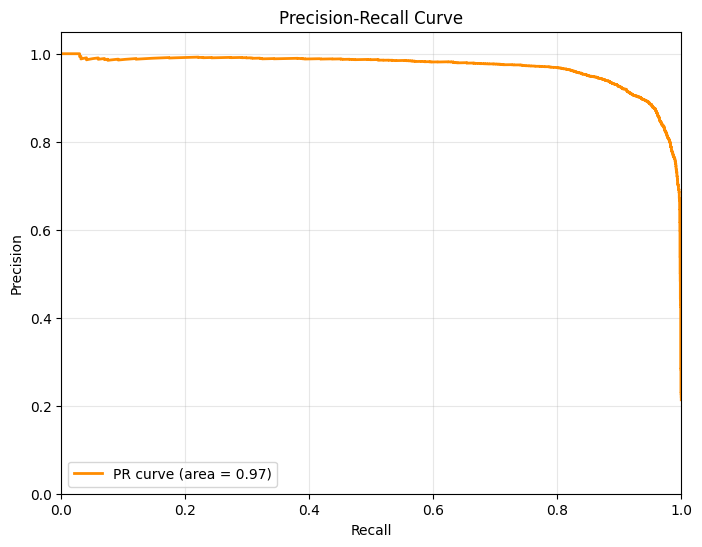

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def plot_precision_recall_curve(loader, model, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            logits = model(data.x, data.edge_index)
            # Get probability for the viral class (index 1)
            probs = F.softmax(logits, dim=1)[:, 1]

            all_probs.append(probs.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    # Flatten the lists
    y_score = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    # Compute Precision-Recall curve and area under curve
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.show()

# Generate the Precision-Recall curve using the test dataset
plot_precision_recall_curve(test_loader, model_gnn, device)